In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
# Load iris dataset
iris = load_iris()

# Create DataFrame with only sepal width and petal length
df = pd.DataFrame({
    'sepal_width': iris.data[:, 1],
    'petal_length': iris.data[:, 2],
    'target': iris.target
})

In [3]:
# Remove Setosa class (target == 0)
df = df[df['target'] != 0]

In [4]:
# Reset index
df = df.reset_index(drop=True)

df.head()

,sepal_width,petal_length,target
0,3.2,4.7,1
1,3.2,4.5,1
2,3.1,4.9,1
3,2.3,4.0,1
4,2.8,4.6,1


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

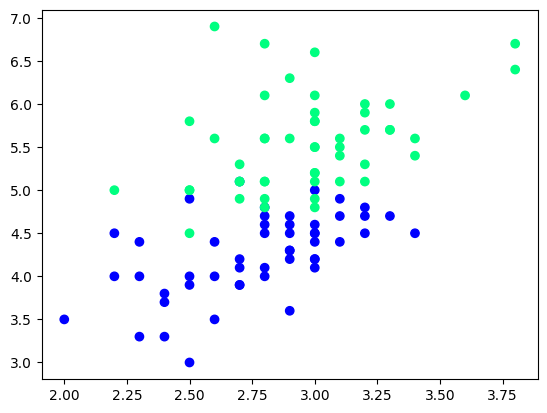

In [6]:
plt.scatter(df['sepal_width'], df['petal_length'], c=df['target'], cmap='winter')
plt.show()

In [7]:
df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [8]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

### Case 1: Bagging

In [9]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal_width,petal_length,target
27,3.0,5.0,1
69,2.2,5.0,2
96,2.5,5.0,2
99,3.0,5.1,2
99,3.0,5.1,2
20,3.2,4.8,1
74,3.3,5.7,2
24,2.9,4.3,1


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [11]:
dt_bag1 = DecisionTreeClassifier()

In [12]:
def evaluate(clf, X, y):
    clf.fit(X, y)

    plot_tree(clf)
    plt.show()

    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.show()

    y_pred = clf.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))

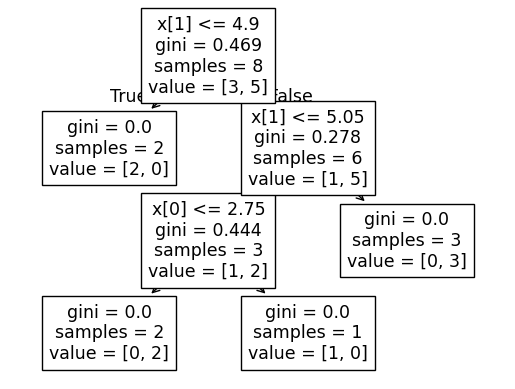

C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


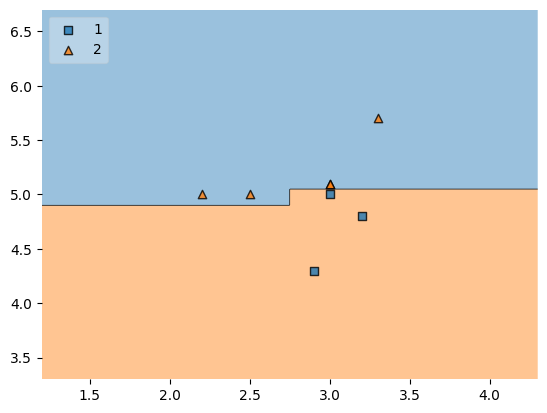

Accuracy: 1.0


C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [13]:
evaluate(dt_bag1, X, y)

In [14]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal_width,petal_length,target
96,2.5,5.0,2
20,3.2,4.8,1
86,3.4,5.6,2
96,2.5,5.0,2
24,2.9,4.3,1
69,2.2,5.0,2
96,2.5,5.0,2
99,3.0,5.1,2


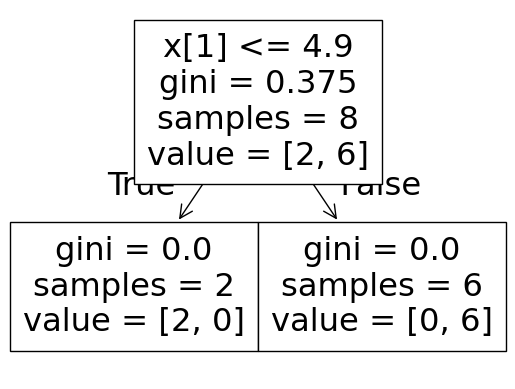

C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


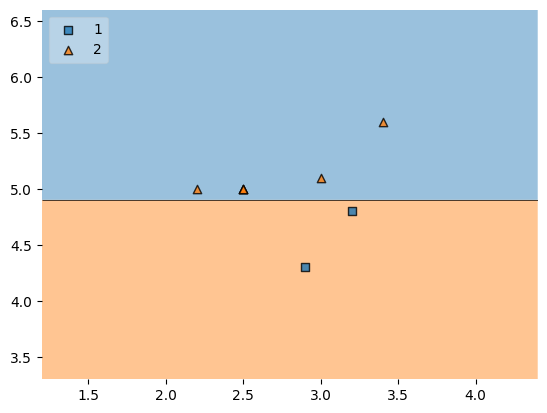

Accuracy: 1.0


C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [15]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

In [16]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal_width,petal_length,target
54,3.0,5.8,2
86,3.4,5.6,2
20,3.2,4.8,1
24,2.9,4.3,1
69,2.2,5.0,2
86,3.4,5.6,2
69,2.2,5.0,2
70,3.2,5.7,2


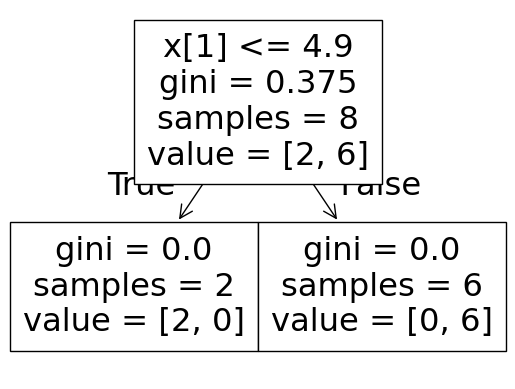

C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


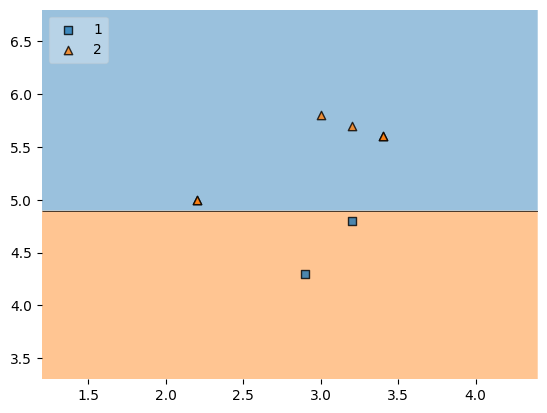

Accuracy: 1.0


C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [17]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

### Predict

In [18]:
df_test

,sepal_width,petal_length,target
46,2.9,4.2,1
52,3.0,5.9,2
81,3.8,6.4,2
61,2.7,5.3,2
88,3.0,4.8,2


In [19]:
print("Predictor 1", dt_bag1.predict(np.array([3.2, 4.7]).reshape(1,2)))
print("Predictor 2", dt_bag2.predict(np.array([3.2, 4.7]).reshape(1,2)))
print("Predictor 3", dt_bag3.predict(np.array([3.2, 4.7]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\alili\.unsloth\studio\unsloth_studio\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
